In [1]:
#importing libaries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
#importing the files
df = pd.read_excel("/content/master_final.xlsx")

In [3]:
#lets begin
print("=" *60)
print("Exploratory Data Analysis")
print("=" *60)

print(f"Rows : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

Exploratory Data Analysis
Rows : 112650
Columns : 39


In [4]:
#lets separate numeric columns
numeric_columns = df.select_dtypes(include = ["number"]).columns

In [5]:
df["price"].describe()

,price
count,112650.000000
mean,120.653739
std,183.633928
min,0.850000
25%,39.900000
50%,74.990000
75%,134.900000
max,6735.000000


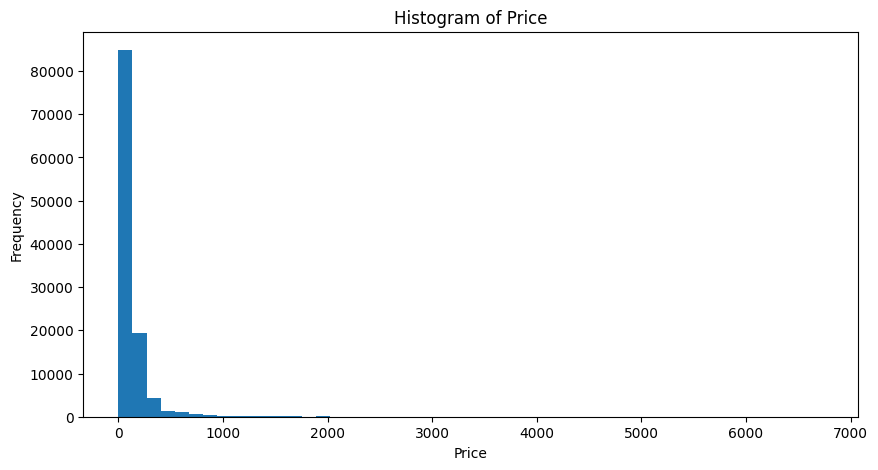

In [6]:
#lets make histogram for price
plt.figure(figsize = (10,5))
plt.hist(df["price"], bins = 50)
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Histogram of Price")
plt.show()

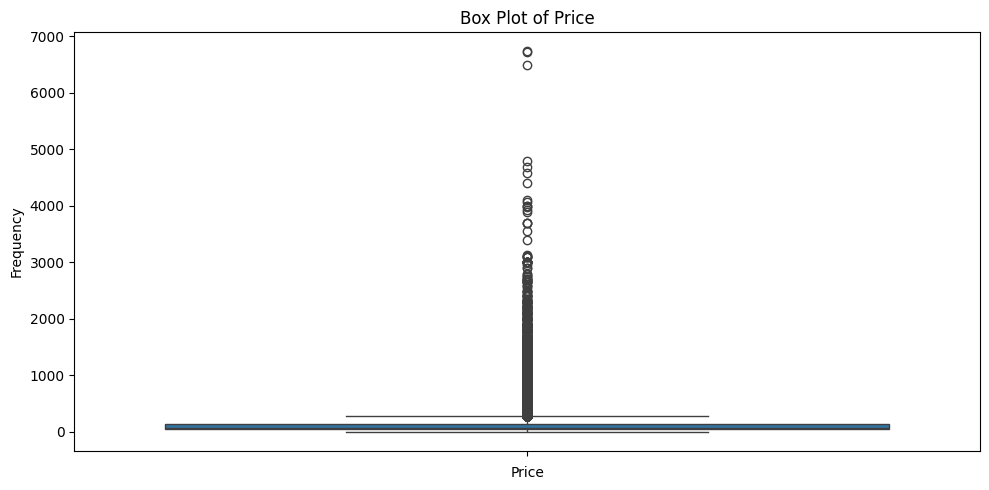

In [7]:
#lets make box plot to understand outlier

plt.figure(figsize = (10,5))
sns.boxplot(df["price"])
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.title("Box Plot of Price")
plt.tight_layout()
plt.show()

In [8]:
#checked the highest price
df.loc[df["price"] == df["price"].max(),["product_id","product_category_name_english","price","seller_state"]]

,product_id,product_category_name_english,price,seller_state
3556,489ae2aa008f021502940f251d4cce7f,housewares,6735.0,SP


In [9]:
## Business Insight

#Product prices exhibit a positively (right) skewed distribution, with most products concentrated in the lower price range.

#A relatively small number of high-value products create a long right tail and substantially increase the average selling price.

#Since the mean is influenced by these premium products, the median provides a more representative measure of a typical product sold on the platform.

In [10]:
## Recommendation

#NovaMart should segment its products into pricing tiers (Budget, Mid-Range, and Premium) rather than relying solely on the overall average price.

#Marketing campaigns, pricing strategies, and inventory planning should be tailored separately for each pricing segment to better reflect customer purchasing behavior.

In [11]:
#freight analysis

df["freight_value"].describe()

,freight_value
count,112650.000000
mean,19.990320
std,15.806405
min,0.000000
25%,13.080000
50%,16.260000
75%,21.150000
max,409.680000


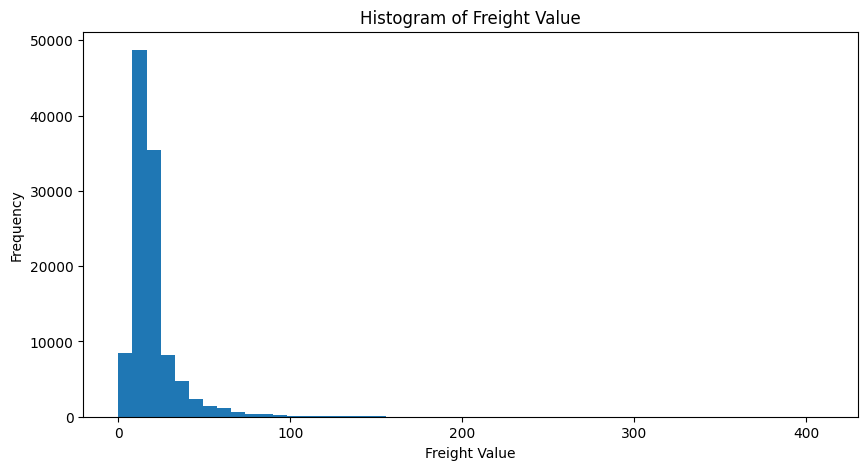

In [12]:
#lets hist the freight values

plt.figure(figsize = (10,5))
plt.hist(df["freight_value"], bins = 50)
plt.xlabel("Freight Value")
plt.ylabel("Frequency")
plt.title("Histogram of Freight Value")
plt.show()

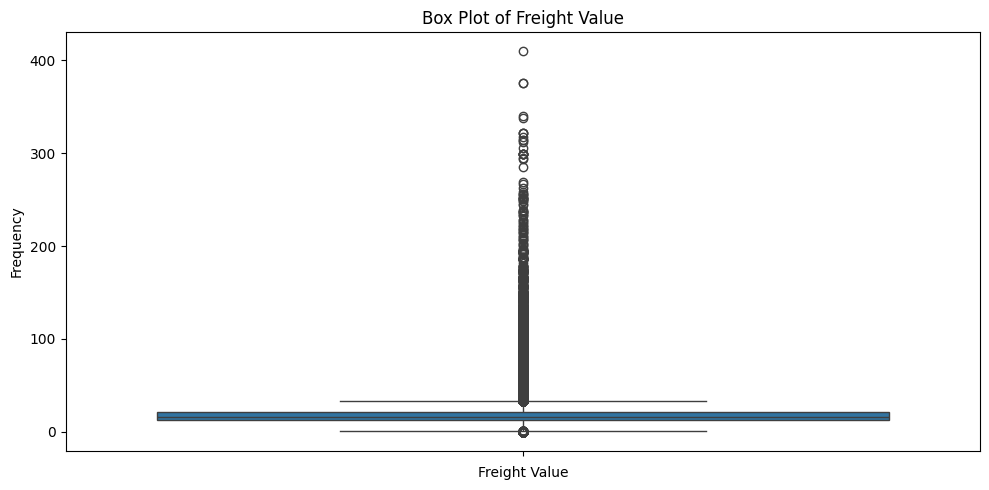

In [13]:
#lets build boxplot of the chart

plt.figure(figsize = (10,5))
sns.boxplot(df["freight_value"])
plt.xlabel("Freight Value")
plt.ylabel("Frequency")
plt.title("Box Plot of Freight Value")
plt.tight_layout()
plt.show()

In [14]:
#correlation between price and freight

corrn = df["price"].corr(df["freight_value"])
print(corrn)

0.41420431036303473


In [15]:
## Business Insight

#Freight charges exhibit a positively skewed distribution, with the majority of orders incurring relatively low shipping costs.

#A small proportion of orders have substantially higher freight charges, increasing the average freight value above the median. These higher shipping costs are likely influenced by product characteristics (size and weight) or delivery distance rather than representing data quality issues.

#The median freight charge better reflects the typical shipping cost experienced by customers.

In [16]:
## Recommendation

#NovaMart should analyze the drivers of high freight charges, such as product dimensions, weight, seller location, and customer region.

#For products with consistently high shipping costs, the business should consider:
#- Optimizing packaging dimensions.
#- Expanding regional warehouse coverage.
#- Negotiating shipping contracts with logistics partners.
#- Offering free shipping only on products where freight costs remain economically sustainable.

In [17]:
#delivery days analysis

df["delivery_days"].describe().T

,delivery_days
count,110196.000000
mean,12.007723
std,9.451455
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


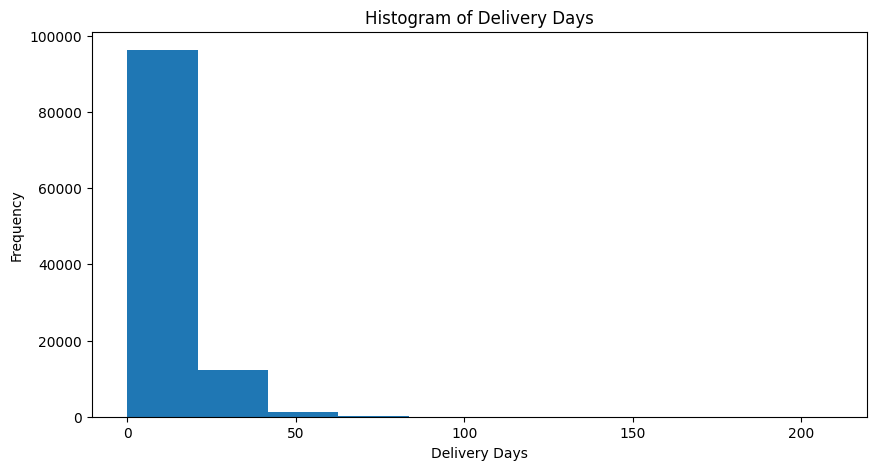

In [18]:
#lets make a hist

plt.figure(figsize = (10,5))
plt.hist(df["delivery_days"], bins = 10)
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.title("Histogram of Delivery Days")
plt.show()

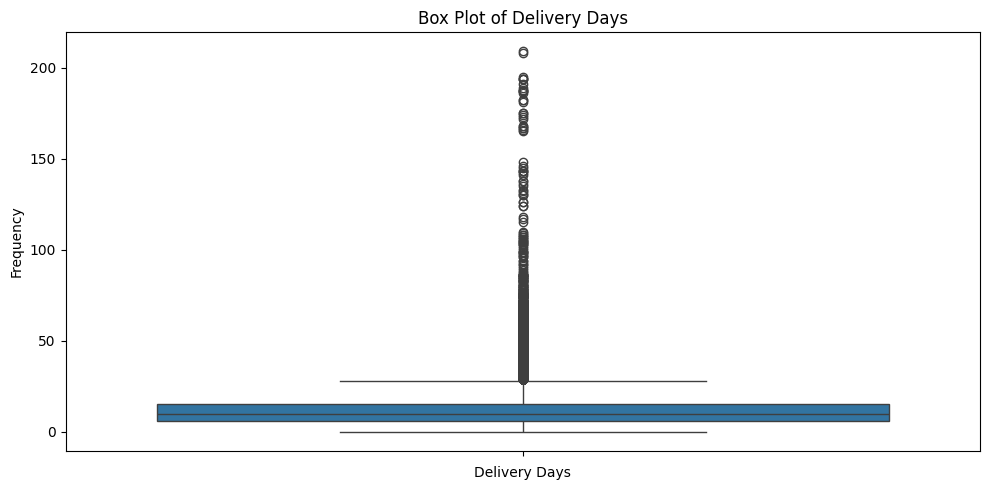

In [19]:
#lets box plot this

plt.figure(figsize = (10,5))
sns.boxplot(df["delivery_days"])
plt.xlabel("Delivery Days")
plt.ylabel("Frequency")
plt.title("Box Plot of Delivery Days")
plt.tight_layout()
plt.show()

In [20]:
#checking the highest delivery day product detail
df.loc[df["delivery_days"] == df["delivery_days"].max(),["product_id","product_category_name_english","price","seller_state","freight_value"]]

,product_id,product_category_name_english,price,seller_state,freight_value
88935,8eed5d27f5b8c6248731efb4782f6141,auto,229.9,MG,15.78


In [21]:
#for futher analysis to check all the seller-state where the delivery date is greater than 30 days
poo = df.loc[df["delivery_days"] >= 30 ,["product_id","product_category_name_english","price","seller_state","freight_value"]]

In [22]:
#seller state
poo["seller_state"].value_counts()

,count
seller_state,
SP,3660
PR,421
MG,373
RJ,186
SC,173
RS,66
MA,41
DF,33
BA,21


In [23]:
## Business Insight

#Delivery times are positively skewed, with most customer orders being delivered within 10–12 days.

#However, a small number of orders experience substantially longer delivery times, resulting in a maximum observed delivery period of 209 days.

#Initial investigation indicates that sellers located in São Paulo (SP) account for the highest number of deliveries exceeding 30 days. Since SP also represents a major seller hub, additional analysis should compare delayed deliveries as a percentage of total orders before concluding that operational performance is worse in this region.

#Bivariate Analysis

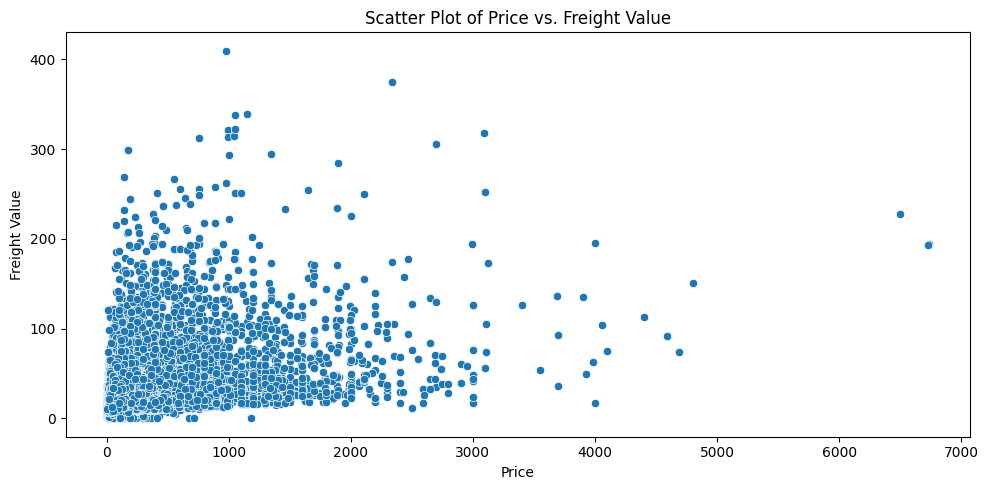

In [24]:
#lets make scatter plot

plt.figure(figsize = (10,5))
sns.scatterplot(x = "price", y = "freight_value", data = df)
plt.xlabel("Price")
plt.ylabel("Freight Value")
plt.title("Scatter Plot of Price vs. Freight Value")
plt.tight_layout()
plt.show()

In [25]:
#pearson correlation

df[["price", "freight_value"]].corr()

,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


In [26]:
### Business Insight

#A moderate positive correlation (0.414) exists between product price and freight value, indicating that higher-priced products generally incur higher shipping charges.

#However, the relationship is not sufficiently strong to conclude that product price is the primary driver of freight cost. This suggests that operational factors such as product weight, dimensions, and shipping distance likely have a greater influence on shipping expenses.

In [27]:
## Recommendation

#NovaMart should avoid estimating shipping costs based solely on product price.

#Future analysis should focus on operational variables such as product weight and package dimensions to better understand the factors driving freight expenses.

#This can support improved logistics planning, shipping cost optimization, and pricing strategies.

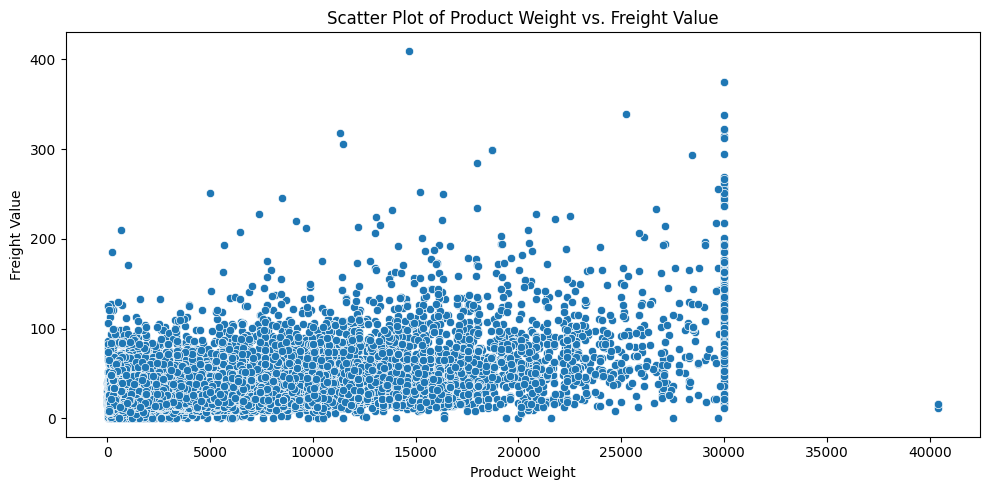

In [28]:
#lets do one hyptothesis analysis between weight and freight value

plt.figure(figsize = (10,5))
sns.scatterplot(x = "product_weight_g", y = "freight_value", data = df)
plt.xlabel("Product Weight")
plt.ylabel("Freight Value")
plt.title("Scatter Plot of Product Weight vs. Freight Value")
plt.tight_layout()
plt.show()

In [29]:
#Pearson correlation

df[["product_weight_g", "freight_value"]].corr()

,product_weight_g,freight_value
product_weight_g,1.00000,0.61042
freight_value,0.61042,1.00000


In [30]:
## Business Insight

#Product weight demonstrates a stronger positive relationship with freight cost (Pearson correlation = 0.610) than product price (Pearson correlation = 0.414).

#This indicates that shipping expenses are influenced more by the physical characteristics of a product than by its monetary value.

#The finding aligns with real-world logistics operations, where freight charges are primarily determined by package weight and handling requirements rather than selling price.

In [31]:
## Recommendation

#NovaMart should optimize logistics using product weight and dimensions instead of product price when estimating shipping costs.

#Future freight prediction models and shipping strategies should prioritize operational variables such as:

#- Product Weight
#- Product Dimensions
#- Seller Location
#- Customer Region

#rather than relying solely on product price.

In [32]:
#grouping by product category and understanding mean,sum and count , sorted by price revenue top 5 values
df.groupby("product_category_name_english").agg(
    price_average=('price', 'mean'),
    price_total_revenue =('price', 'sum'),
    freight_value_average=('freight_value', 'mean'),
    freight_value_total_revenuew =('freight_value', 'sum'),
    order_count=('order_id', 'count'),
    average_freight_ratio = ("freight_ratio","mean")
).sort_values(by = "price_total_revenue", ascending = False).head(10)


,price_average,price_total_revenue,freight_value_average,freight_value_total_revenuew,order_count,average_freight_ratio
product_category_name_english,,,,,,
health_beauty,130.163531,1258681.34,18.879703,182566.73,9670,30.190796
watches_gifts,201.135984,1205005.68,16.781160,100535.93,5991,17.077283
bed_bath_table,93.296327,1036988.68,18.415928,204693.04,11115,28.424561
sports_leisure,114.344285,988048.97,19.512500,168607.51,8641,29.385835
computers_accessories,116.513903,911954.32,18.821781,147318.08,7827,29.429283
furniture_decor,87.564494,729762.49,20.728258,172749.30,8334,34.671586
cool_stuff,167.357969,635290.85,22.138857,84039.10,3796,22.022919
housewares,90.788148,632248.66,20.986374,146149.11,6964,40.270678
auto,139.957523,592720.11,21.880569,92664.21,4235,33.150649


In [33]:
# Filter for 'health_beauty' category
health_beauty_df = df[df['product_category_name_english'] == 'health_beauty']

# Count orders per seller state for 'health_beauty' category
orders_by_state = health_beauty_df['seller_state'].value_counts().reset_index()
orders_by_state.columns = ['seller_state', 'number_of_orders']

display(orders_by_state)

,seller_state,number_of_orders
0,SP,6404
1,RJ,1071
2,PR,663
3,MG,407
4,MA,405
5,SC,271
6,RS,151
7,DF,139
8,MT,52
9,GO,32


In [34]:
## Business Insight

#While Health Beauty remains NovaMart's highest revenue-generating category, Housewares exhibits the highest average freight burden relative to product price.

#This suggests that logistics costs consume a larger proportion of revenue for lower-priced, bulkier products.

#Conversely, premium categories such as Watches & Gifts maintain relatively low freight ratios despite higher selling prices, making them operationally more efficient.

In [35]:
## Recommendation

#NovaMart should consider category-specific shipping strategies rather than applying uniform shipping policies.

#Recommendations include:

#- Prioritize free shipping promotions for high-value categories with lower freight ratios.
#- Review packaging and logistics for categories with consistently high freight burdens.
#- Evaluate warehouse placement and carrier optimization for Housewares, Furniture Decor, and Garden Tools.
#- Consider minimum purchase thresholds before offering free shipping on categories with high logistics costs.

In [36]:
#we are trying to find high revenue, high demand, low logistics cost

categories_summary = (df.groupby('product_category_name_english').agg(
    total_revenue=('price', 'sum'),
    total_orders=('order_id', 'count'),
    average_freight_ratio=('freight_ratio', 'mean'),
    average_price = ('price', 'mean')
)).reset_index()

In [37]:
categories_summary.nlargest(10, 'total_revenue')

,product_category_name_english,total_revenue,total_orders,average_freight_ratio,average_price
45,health_beauty,1258681.34,9670,30.190796,130.163531
72,watches_gifts,1205005.68,5991,17.077283,201.135984
9,bed_bath_table,1036988.68,11115,28.424561,93.296327
67,sports_leisure,988048.97,8641,29.385835,114.344285
17,computers_accessories,911954.32,7827,29.429283,116.513903
41,furniture_decor,729762.49,8334,34.671586,87.564494
22,cool_stuff,635290.85,3796,22.022919,167.357969
51,housewares,632248.66,6964,40.270678,90.788148
7,auto,592720.11,4235,33.150649,139.957523
44,garden_tools,485256.46,4347,33.137336,111.630196


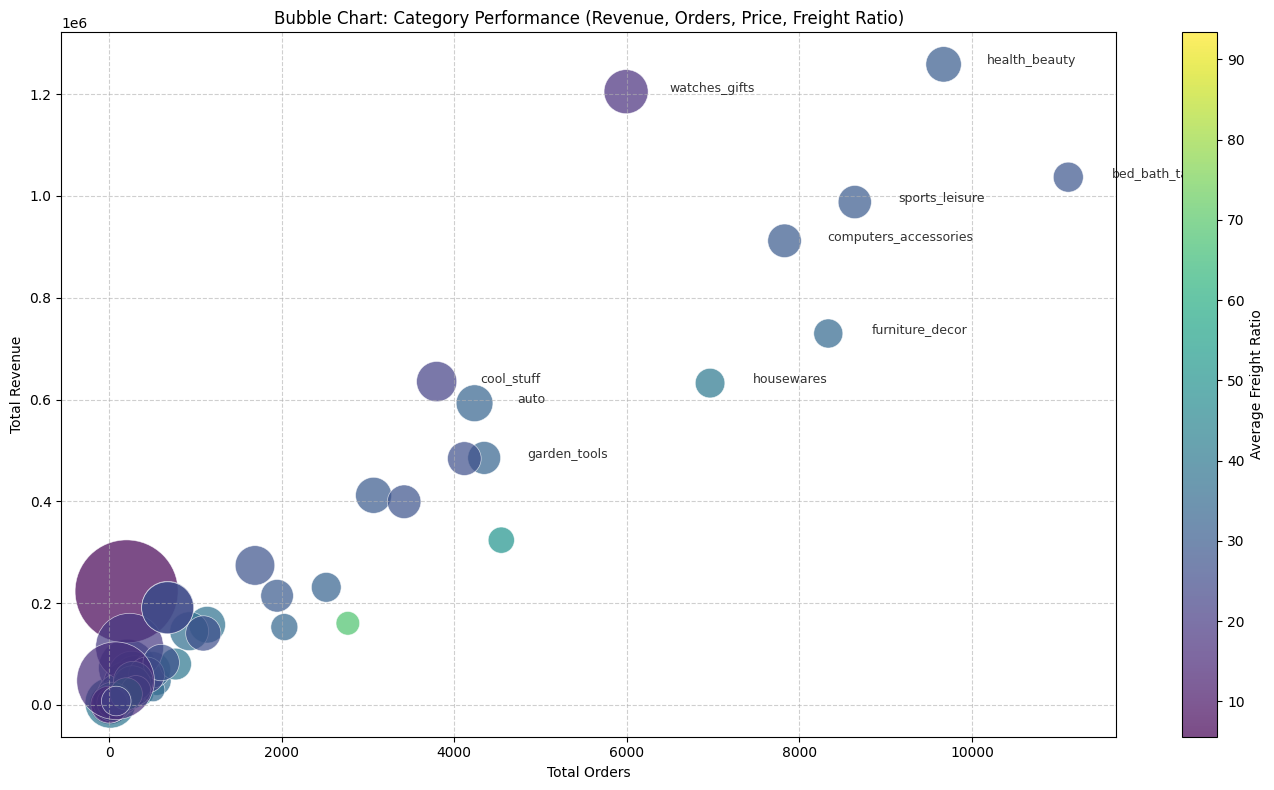

In [38]:
# Create a bubble chart for categories summary

plt.figure(figsize=(14, 8))

scatter = plt.scatter(
    categories_summary['total_orders'],
    categories_summary['total_revenue'],
    s=categories_summary['average_price'] * 5, # Scale size for visibility
    c=categories_summary['average_freight_ratio'],
    cmap='viridis', # Choose a colormap
    alpha=0.7, # Set transparency
    edgecolors='w', # Add white edges to bubbles
    linewidth=0.5
)

top_n_categories = categories_summary.nlargest(10, 'total_revenue')
for i, row in top_n_categories.iterrows():
    plt.text(
        row['total_orders'] + 500, # Offset text slightly to the right
        row['total_revenue'],
        row['product_category_name_english'],
        fontsize=9,
        alpha=0.8
    )

plt.xlabel('Total Orders')
plt.ylabel('Total Revenue')
plt.title('Bubble Chart: Category Performance (Revenue, Orders, Price, Freight Ratio)')
plt.grid(True, linestyle='--', alpha=0.6)

# Add a color bar for average_freight_ratio
cbar = plt.colorbar(scatter)
cbar.set_label('Average Freight Ratio')

plt.tight_layout()
plt.show()

In [39]:
#question 2 : which seller state performs the best

seller_group = (df.groupby("seller_state").agg(
    total_revenue=('price', 'sum'),
    average_delivery = ("delivery_days", "mean"),
    total_orders = ("order_id", "count")
)).reset_index().sort_values(by = "total_revenue", ascending = False).head(10)

In [40]:
print(seller_group)

   seller_state  total_revenue  average_delivery  total_orders
22           SP     8753396.21         11.811387         80342
15           PR     1261887.21         12.921763          8671
8            MG     1011564.74         12.329691          8827
16           RJ      843984.22         11.554916          4818
20           SC      632426.07         13.095500          4075
19           RS      378559.54         11.092208          2199
2            BA      285561.56         13.413462           643
4            DF       97749.48         12.088335           899
13           PE       91493.85         12.496629           448
6            GO       66399.21         12.370079           520


In [41]:
#question 3 : which month derives novamart's business?

month_group = (df.groupby(df["order_purchase_timestamp"].dt.month_name()).agg(
    total_revenue = ("price", "sum"),
    total_orders = ("order_id", "count"),
    average_order_value_per_month = ("price", "mean")
).reset_index()).sort_values(by = "total_revenue", ascending = False)

In [42]:
month_group

,order_purchase_timestamp,total_revenue,total_orders,average_order_value_per_month
8,May,1502588.82,12061,124.582441
1,August,1428658.01,12158,117.507650
5,July,1393538.70,11611,120.018836
7,March,1357557.74,11217,121.026811
0,April,1356574.98,10659,127.270380
6,June,1298162.91,10661,121.767462
3,February,1091481.73,9623,113.424268
4,January,1070343.23,9163,116.811441
9,November,1010271.37,8665,116.592195
2,December,743925.07,6309,117.914895


In [43]:
#question 4: which customer state generates highest revenue?

customer_state_group = (df.groupby("customer_state").agg(
    total_revenue = ("price", "sum"))).reset_index().sort_values(by = "total_revenue", ascending = False)

In [47]:
customer_state_group

,customer_state,total_revenue
25,SP,5202955.05
18,RJ,1824092.67
10,MG,1585308.03
22,RS,750304.02
17,PR,683083.76
23,SC,520553.34
4,BA,511349.99
6,DF,302603.94
8,GO,294591.95
7,ES,275037.31


In [44]:
#question 5: Delivery performance

total_unique_orders_overall = df["order_id"].nunique()

delivery_group = df.groupby("order_status").agg(
    total_orders = ("order_id", "nunique") # Count unique order IDs for each status
)

In [45]:
delivery_group["percentage"] = delivery_group["total_orders"].apply(lambda x : (x/total_unique_orders_overall) * 100)

In [46]:
delivery_group.sort_values(by = "percentage", ascending = False)

,total_orders,percentage
order_status,,
delivered,96478,97.782417
shipped,1106,1.120954
canceled,461,0.467233
invoiced,312,0.316218
processing,301,0.305070
unavailable,6,0.006081
approved,2,0.002027


In [60]:
#question 6 RFM Analysis, customer frequency

customer_frequency = (df.groupby("customer_unique_id").agg(
    total_orders = ("order_id", "nunique"),
    total_spent = ("price", "sum"),
    average_spent = ("price", "mean")
)).reset_index().sort_values(by = "total_orders", ascending = False)

In [62]:
customer_frequency.head(20)

,customer_unique_id,total_orders,total_spent,average_spent
52597,8d50f5eadf50201ccdcedfb9e2ac8455,16,729.62,45.601250
23302,3e43e6105506432c953e165fb2acf44c,9,1000.85,71.489286
10281,1b6c7548a2a1f9037c1fd3ddfed95f33,7,809.21,89.912222
75560,ca77025e7201e3b30c44b472ff346268,7,806.61,67.217500
37532,6469f99c1f9dfae7733b25662e7f1782,7,664.20,73.800000
89814,f0e310a6839dce9de1638e0fe5ab282a,6,438.09,73.015000
37320,63cfc61cee11cbe306bff5857d00bfe4,6,579.81,52.710000
82305,dc813062e0fc23409cd255f7f53c7074,6,687.76,62.523636
26849,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,836.60,119.514286
7124,12f5d6e1cbf93dafd9dcc19095df0b3d,6,58.40,9.733333


In [67]:
#customer distribution
customer_frequency["total_orders"].value_counts().reset_index()

,total_orders,count
0,1,92507
1,2,2673
2,3,192
3,4,29
4,5,9
5,6,5
6,7,3
7,16,1
8,9,1


In [81]:
#chunking customers

customer_frequency["customer_segment"] = pd.cut(customer_frequency["total_spent"],bins = [0,100,500,1000,5000,100000],labels = ["Low Value","Medium Value","High Value","Premium","VIP"])

In [82]:
customer_frequency["customer_segment"].value_counts()

,count
customer_segment,
Low Value,54665
Medium Value,37002
High Value,2778
Premium,968
VIP,7


In [83]:
customer_frequency.sort_values(by = "total_orders", ascending = False).head(10)

,customer_unique_id,total_orders,total_spent,average_spent,customer_segment
52597,8d50f5eadf50201ccdcedfb9e2ac8455,16,729.62,45.601250,High Value
23302,3e43e6105506432c953e165fb2acf44c,9,1000.85,71.489286,Premium
37532,6469f99c1f9dfae7733b25662e7f1782,7,664.20,73.800000,High Value
75560,ca77025e7201e3b30c44b472ff346268,7,806.61,67.217500,High Value
10281,1b6c7548a2a1f9037c1fd3ddfed95f33,7,809.21,89.912222,High Value
89814,f0e310a6839dce9de1638e0fe5ab282a,6,438.09,73.015000,Medium Value
37320,63cfc61cee11cbe306bff5857d00bfe4,6,579.81,52.710000,High Value
82305,dc813062e0fc23409cd255f7f53c7074,6,687.76,62.523636,High Value
26849,47c1a3033b8b77b3ab6e109eb4d5fdf3,6,836.60,119.514286,High Value
7124,12f5d6e1cbf93dafd9dcc19095df0b3d,6,58.40,9.733333,Low Value


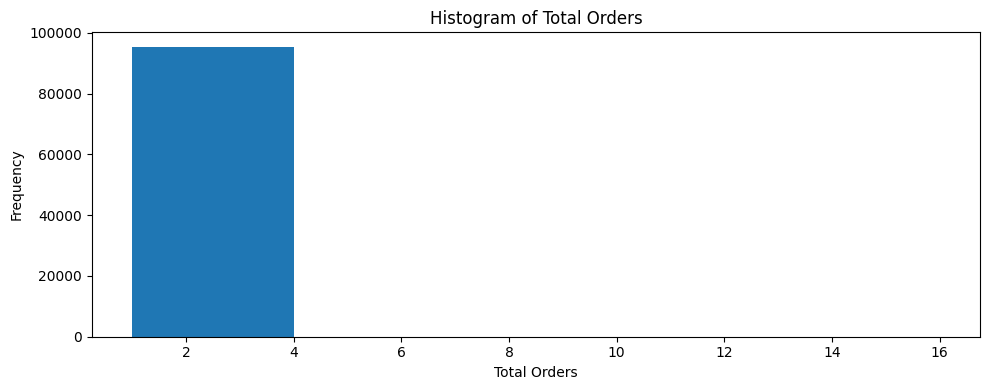

In [84]:
#histogram of customer distribution

plt.figure(figsize = (10,4))

plt.hist(customer_frequency["total_orders"], bins = 5)
plt.xlabel("Total Orders")
plt.ylabel("Frequency")
plt.title("Histogram of Total Orders")
plt.tight_layout()
plt.show()

In [74]:
## Business Insight

#NovaMart's customer base is heavily dominated by one-time purchasers, with approximately 97% of customers placing only a single order.

#Although the company demonstrates strong customer acquisition, repeat purchasing behavior is extremely limited.

#This suggests that future revenue growth depends heavily on acquiring new customers rather than retaining existing ones.

In [75]:
## Recommendation

#NovaMart should prioritize customer retention initiatives, including:

#- Loyalty and rewards programs
#- Personalized email campaigns
#- Post-purchase engagement
#- Product recommendations
#- Discount incentives for second purchases

#Improving repeat purchase behavior is likely to increase Customer Lifetime Value (CLV) while reducing customer acquisition costs.

In [88]:
#overall table

overall = pd.DataFrame({
    "Total Customers" : [df["customer_unique_id"].nunique()],
    "One Time Customers" : [customer_frequency[customer_frequency["total_orders"] == 1]["customer_unique_id"].nunique()],
    "Repeat Customers" : [customer_frequency[customer_frequency["total_orders"] > 1]["customer_unique_id"].nunique()],
    "Repeat Purchase Rate" : [round((customer_frequency[customer_frequency["total_orders"] > 1]["customer_unique_id"].nunique() / df["customer_unique_id"].nunique()) * 100,2)],
    "Average Customer Spend" : [round(customer_frequency["total_spent"].mean(),2)],
    "Average Order Per Customer" : [round(customer_frequency["total_orders"].mean(),2)]
})

In [90]:
overall.T

,0
Total Customers,95420.00
One Time Customers,92507.00
Repeat Customers,2913.00
Repeat Purchase Rate,3.05
Average Customer Spend,142.44
Average Order Per Customer,1.03


In [91]:
## Business Insight

#NovaMart demonstrates strong customer acquisition with over 95,000 unique customers.

#However, approximately **97% of customers purchase only once**, resulting in a **Repeat Purchase Rate of just 3.05%**.

#The Average Orders per Customer is only **1.03**, indicating that nearly all revenue depends on acquiring new customers rather than encouraging repeat purchases.

#This represents NovaMart's largest business opportunity.